In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams["figure.figsize"] = (8, 5)




---



General Inspection

In [ ]:
df = pd.read_csv('/content/_wine_clustering.csv')
df.head()

,alcohol,malic_acid,flavanoids,color_intensity,proline
0,14.23,1.71,3.06,5.64,1065.0
1,13.20,1.78,2.76,4.38,1050.0
2,13.16,2.36,3.24,5.68,1185.0
3,14.37,1.95,3.49,7.80,1480.0
4,13.24,2.59,2.69,4.32,735.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   alcohol          178 non-null    float64
 1   malic_acid       178 non-null    float64
 2   flavanoids       178 non-null    float64
 3   color_intensity  178 non-null    float64
 4   proline          178 non-null    float64
dtypes: float64(5)
memory usage: 7.1 KB


In [ ]:
df.shape

(178, 5)

In [ ]:
X = df.copy()
print(f"Features used for clustering: {X.columns.tolist()}")

Features used for clustering: ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity', 'proline']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,alcohol,malic_acid,flavanoids,color_intensity,proline
0,1.518613,-0.562250,1.034819,0.251717,1.013009
1,0.246290,-0.499413,0.733629,-0.293321,0.965242
2,0.196879,0.021231,1.215533,0.269020,1.395148
3,1.691550,-0.346811,1.466525,1.186068,2.334574
4,0.295700,0.227694,0.663351,-0.319276,-0.037874




---






**KMeans Clustering**



1.   Finding the most suitable k value



In [ ]:
k_values = range(2,7) # Possible k values: 2, 3, 4, 5, 6

results = [] # Stores results


for k in k_values:
  model = KMeans(n_clusters=k, random_state=42, n_init=20) #Tests 20 different starting points
  labels = model.fit_predict(X_scaled) #Train & return labels
  inertia_value = model.inertia_ # Measuring within-cluster spread
  silhouette_value = silhouette_score(X_scaled, labels) # Measuring clusters spread
  results.append({
      'k': k,
      'inertia': inertia_value,
      'silhouette score': silhouette_value
  })


kmeans_eval = pd.DataFrame(results)

print("KMeans evaluation table:")
display(kmeans_eval.round(4))


KMeans evaluation table:


,k,inertia,silhouette score
0,2,591.0345,0.3342
1,3,358.0601,0.4182
2,4,306.8912,0.3755
3,5,273.9672,0.3592
4,6,242.4674,0.3005


The KMeans model with the highest silhouette score (0.4182) has 3 clusters



---



2. 3 KMeans clustering model

In [ ]:
clustering_model = KMeans(n_clusters=3, random_state=42, n_init=20)
df['kmeans_cluster'] = clustering_model.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, df["kmeans_cluster"])
print(f"KMeans silhouette score: {kmeans_silhouette:.4f}")


KMeans silhouette score: 0.4182


In [ ]:
df.head() #Cluster labels added to the dataframe

,alcohol,malic_acid,flavanoids,color_intensity,proline,kmeans_cluster
0,14.23,1.71,3.06,5.64,1065.0,2
1,13.20,1.78,2.76,4.38,1050.0,2
2,13.16,2.36,3.24,5.68,1185.0,2
3,14.37,1.95,3.49,7.80,1480.0,2
4,13.24,2.59,2.69,4.32,735.0,2


In [ ]:
print("\nPer cluster counts:")
display(
    df["kmeans_cluster"]
      .value_counts()
      .sort_index()
      .rename_axis("cluster")
      .to_frame(name="row_count")
)


Per cluster counts:


,row_count
cluster,
0,71
1,50
2,57




---



3. **Cluster Profile:** summarizing the characteristics of each cluster

In [ ]:
kmeans_profile = (
    df.groupby("kmeans_cluster")
      .agg(
          cluster_size = ("alcohol", "count"),
          mean_alcohol = ("alcohol", "mean"),
          mean_malic_acid = ("malic_acid", "mean"),
          mean_flavanoids = ("flavanoids", "mean"),
          mean_color_intensity = ("color_intensity", "mean"),
          mean_proline = ("proline", "mean")
    ).round(2)
)

print("KMeans cluster profile:")
display(kmeans_profile)

KMeans cluster profile:


,cluster_size,mean_alcohol,mean_malic_acid,mean_flavanoids,mean_color_intensity,mean_proline
kmeans_cluster,,,,,,
0,71,12.27,1.84,2.04,3.12,522.75
1,50,13.17,3.50,0.90,7.23,626.00
2,57,13.77,1.94,3.00,5.56,1132.14


Comment: the centroids of each cluster appear to be different in the colour intensity and proline values mainly



---



4. Visualizing clusters

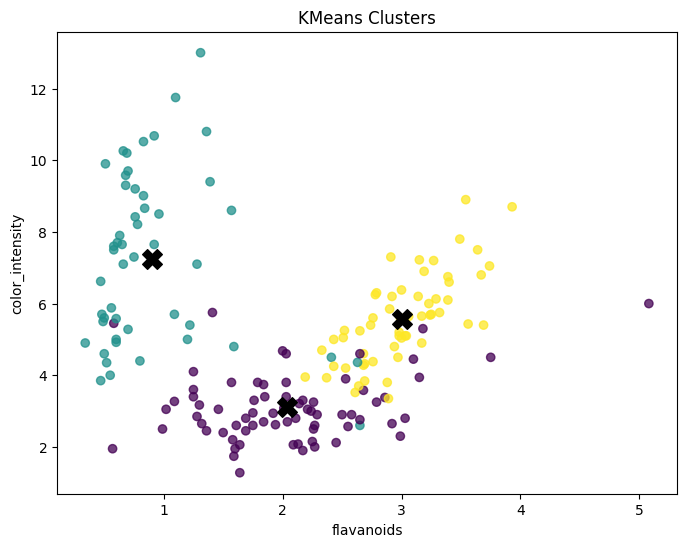

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["flavanoids"],
    df["color_intensity"],
    c=df["kmeans_cluster"],
    alpha=0.75
)

plt.scatter(
    kmeans_profile["mean_flavanoids"],
    kmeans_profile["mean_color_intensity"],
    marker="X",
    s=200,
    c="black"
)

plt.xlabel("flavanoids")
plt.ylabel("color_intensity")
plt.title("KMeans Clusters")
plt.show()



---



**Hierarchical Clustering**

1. Clustering model results (with three clusters)

In [ ]:
hier_model = AgglomerativeClustering(n_clusters=3, linkage="ward")

df["hierarchical_cluster"] = hier_model.fit_predict(X_scaled)

hier_silhouette = silhouette_score(X_scaled, df["hierarchical_cluster"])

print(f"Hierarchical clustering silhouette score: {hier_silhouette:.4f}")

print("\nCluster counts for hierarchical clustering:")
display(
    df["hierarchical_cluster"]
      .value_counts()
      .sort_index()
      .rename_axis("cluster")
      .to_frame(name="row_count")
)


Hierarchical clustering silhouette score: 0.4157

Cluster counts for hierarchical clustering:


,row_count
cluster,
0,49
1,60
2,69


2. Ward-linkage dendrogram

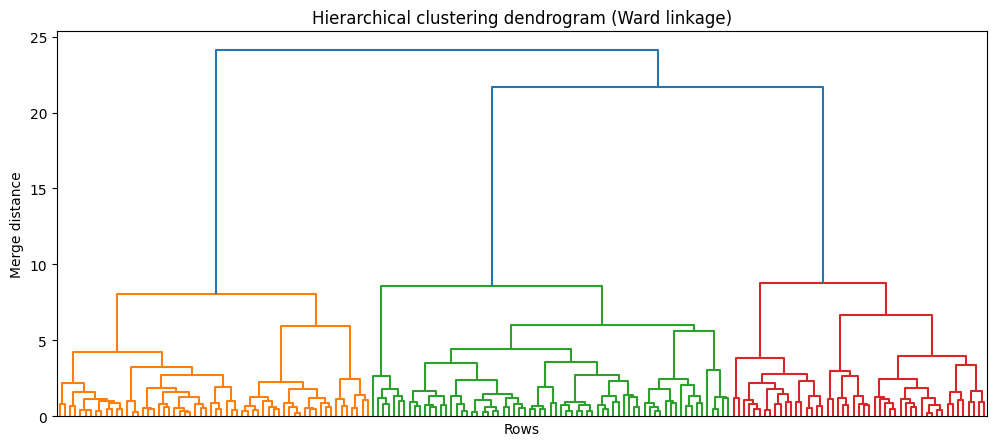

In [ ]:
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, no_labels=True)
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("Rows")
plt.ylabel("Merge distance")
plt.show()

3. Clustering profile

In [ ]:
kmeans_profile = (
    df.groupby("hierarchical_cluster")
      .agg(
          cluster_size = ("alcohol", "count"),
          mean_alcohol = ("alcohol", "mean"),
          mean_malic_acid = ("malic_acid", "mean"),
          mean_flavanoids = ("flavanoids", "mean"),
          mean_color_intensity = ("color_intensity", "mean"),
          mean_proline = ("proline", "mean")
    ).round(2)
)

print("Hierarchical cluster profile:")
display(kmeans_profile)

Hierarchical cluster profile:


,cluster_size,mean_alcohol,mean_malic_acid,mean_flavanoids,mean_color_intensity,mean_proline
hierarchical_cluster,,,,,,
0,49,13.15,3.39,0.80,7.33,622.29
1,60,13.73,2.00,2.98,5.49,1113.53
2,69,12.26,1.88,2.08,3.07,516.57




---



In [ ]:
comp = {
    'Method': ['KMeans', 'Hierarchical (Ward)'],
    'n_clusters': [3, 3],
    'KMeans Silhouette': [kmeans_silhouette, hier_silhouette]
}

comp_df = pd.DataFrame(comp).round(4)
comp_df

,Method,n_clusters,KMeans Silhouette
0,KMeans,3,0.4182
1,Hierarchical (Ward),3,0.4157


Conclusion:\
Cluster 0: (49 wines) has the highest malic acid (3.39), very low flavanoids (0.80), and low proline (622), and the highest colour intensity (7.33). \
Cluster 1: (60 wines) has strong flavanoids (2.98), and by far the highest proline (1113).\
Cluster 2: (69 wines) has the lowest averages across all features except flavanoids, color intensity (3.07), proline (516.57), malic acid (1.88).